#### Loading the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import load

from sklearn.inspection import permutation_importance

#### Loading the Final Model

In [3]:
import os

model_files = os.listdir('../models')

model_files

['decision_tree_classifier_pipeline.joblib',
 'extra_trees_classifier_pipeline.joblib',
 'gradient_boosting_classifier_pipeline.joblib',
 'hist_gradient_boosting_classifier_pipeline.joblib',
 'logistic_regression_pipeline.joblib',
 'random_forest_classifier_pipeline.joblib',
 'ridge_classifier_pipeline.joblib',
 'stacking_classifier_pipeline.joblib',
 'tuned_extra_trees_classifier_pipeline.joblib',
 'tuned_gradient_boosting_classifier_pipeline.joblib',
 'tuned_hist_gradient_boosting_classifier_pipeline.joblib',
 'tuned_random_forest_classifier_pipeline.joblib',
 'tuned_xgboost_classifier_pipeline.joblib',
 'voting_classifier_pipeline.joblib',
 'xgboost_classifier_pipeline.joblib']

In [4]:
final_model = load(
    '../models/gradient_boosting_classifier_pipeline.joblib'
)

final_model

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[bool](2,)","[False, True]"
feature_names_in_,"ndarray[object](22,)","['Administrative','Administrative_Duration','Informational',..., 'Product_Page_Share','Avg_Duration_Per_Page','Product_Duration_Share']"
n_features_in_,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


#### Loading the Test Dataset

In [5]:
test_data = pd.read_csv(
    '../data/processed/test_data.csv'
)

X_test = test_data.drop(
    'Revenue',
    axis=1
)

y_test = test_data['Revenue']

The pipeline contains the ColumnTransformer, which scales numerical features, one-hot encodes categorical features, and passes the binary feature through. So the model sees more features than the original 22 columns

#### Extracting Transformed Feature Names

In [6]:
preprocessor = final_model.named_steps[
    'preprocessor'
]

transformed_feature_names = (
    preprocessor.get_feature_names_out()
)

len(transformed_feature_names), transformed_feature_names

(78,
 array(['numerical__Administrative', 'numerical__Administrative_Duration',
        'numerical__Informational', 'numerical__Informational_Duration',
        'numerical__ProductRelated', 'numerical__ProductRelated_Duration',
        'numerical__BounceRates', 'numerical__ExitRates',
        'numerical__PageValues', 'numerical__SpecialDay',
        'numerical__Total_Pages_Viewed',
        'numerical__Total_Browsing_Duration',
        'numerical__Product_Page_Share',
        'numerical__Avg_Duration_Per_Page',
        'numerical__Product_Duration_Share', 'categorical__Month_Aug',
        'categorical__Month_Dec', 'categorical__Month_Feb',
        'categorical__Month_Jul', 'categorical__Month_June',
        'categorical__Month_Mar', 'categorical__Month_May',
        'categorical__Month_Nov', 'categorical__Month_Oct',
        'categorical__Month_Sep', 'categorical__OperatingSystems_1',
        'categorical__OperatingSystems_2',
        'categorical__OperatingSystems_3',
        'categori

#### Calculating Feature Importance

In [8]:
final_model.named_steps

{'preprocessor': ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                  ['Administrative', 'Administrative_Duration',
                                   'Informational', 'Informational_Duration',
                                   'ProductRelated', 'ProductRelated_Duration',
                                   'BounceRates', 'ExitRates', 'PageValues',
                                   'SpecialDay', 'Total_Pages_Viewed',
                                   'Total_Browsing_Duration',
                                   'Product_Page_Share', 'Avg_Duration_Per_Page',
                                   'Product_Duration_Share']),
                                 ('categorical',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  ['Month', 'OperatingSystems', 'Browser',
                                   'Region', 'TrafficType',

In [9]:
model = final_model.named_steps[
    'model'
]

feature_importance = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,numerical__PageValues,0.749870
1,categorical__Month_Nov,0.098325
2,categorical__TrafficType_2,0.029306
3,numerical__Administrative,0.013465
4,numerical__Product_Page_Share,0.009530
5,categorical__Region_1,0.009025
6,numerical__Informational,0.006623
7,categorical__Month_May,0.006474
8,numerical__Total_Pages_Viewed,0.005852
9,binary__Weekend,0.005453


That's a very strong and interesting result, man. PageValues is dominating the model with ~75% of the total tree-based importance, while the remaining importance is distributed across several behavioral and session-context features.

But there's an important explainability issue here: because categorical variables were one-hot encoded, Month_Nov, TrafficType_2, etc. are only parts of their original features.

So next we'll aggregate those one-hot features back to their original business-level features. This is much more portfolio-quality than simply presenting the encoded columns.

#### Aggregating Feature Importance

In [10]:
feature_importance['Original_Feature'] = (
    feature_importance['Feature']
    .str.replace(
        r'^(numerical|categorical|binary)__',
        '',
        regex=True
    )
)

categorical_prefixes = [
    'Month_',
    'OperatingSystems_',
    'Browser_',
    'Region_',
    'TrafficType_',
    'VisitorType_'
]

for prefix in categorical_prefixes:
    mask = feature_importance['Original_Feature'].str.startswith(prefix)

    feature_importance.loc[
        mask,
        'Original_Feature'
    ] = prefix.rstrip('_')

aggregated_importance = (
    feature_importance
    .groupby(
        'Original_Feature',
        as_index=False
    )['Importance']
    .sum()
    .sort_values(
        'Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

aggregated_importance

,Original_Feature,Importance
0,PageValues,0.749870
1,Month,0.111678
2,TrafficType,0.041473
3,Region,0.018451
4,Administrative,0.013465
5,Product_Page_Share,0.009530
6,VisitorType,0.008227
7,Informational,0.006623
8,Total_Pages_Viewed,0.005852
9,Weekend,0.005453


#### Visualizing Feature Importance

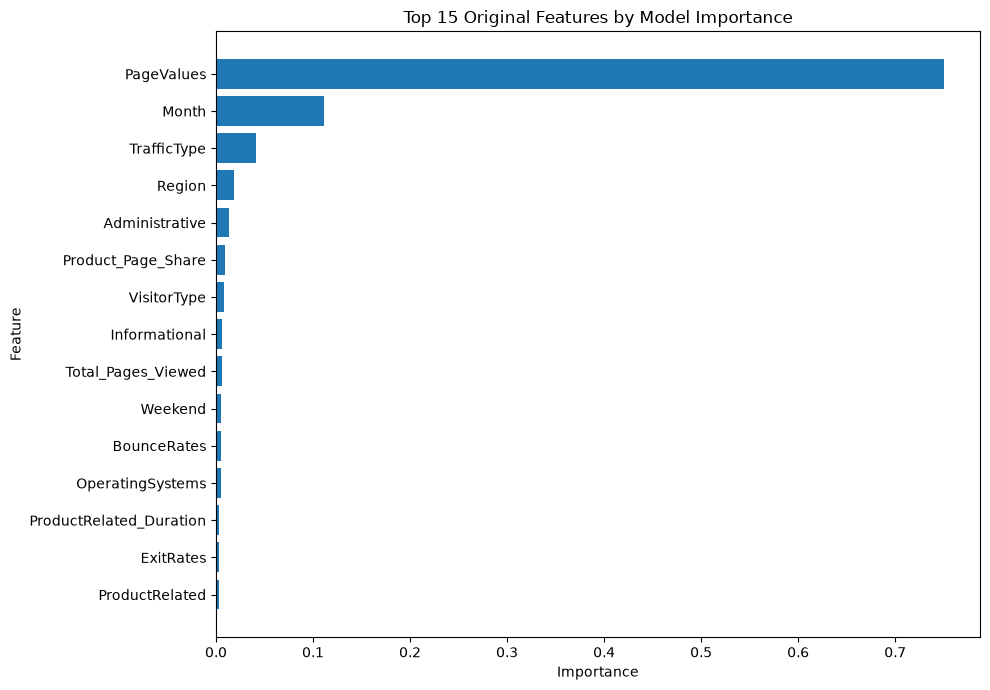

In [11]:
top_features = (
    aggregated_importance
    .head(15)
    .sort_values(
        'Importance',
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Original_Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Original Features by Model Importance')

plt.tight_layout()
plt.show()

Now we'll add something more robust than built-in tree importance: Permutation Importance.

This is valuable because it measures how much the model's performance changes when each feature is shuffled on the unseen test data. It gives us a model-agnostic view and helps validate whether the built-in importance ranking is telling the same story.

We'll use F1 as the scoring metric because that's the primary metric we selected for this project.

#### Calculating Permutation Importance

In [12]:
permutation_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42,
    n_jobs=-2
)

permutation_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': permutation_result.importances_mean,
    'Importance_Std': permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        'Importance_Mean',
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_df.head(15)

,Feature,Importance_Mean,Importance_Std
0,PageValues,0.505812,0.014998
1,Month,0.033740,0.008244
2,Administrative,0.009257,0.003483
3,BounceRates,0.007881,0.003408
4,TrafficType,0.007641,0.003311
5,ExitRates,0.006892,0.004348
6,Region,0.006003,0.002275
7,Total_Browsing_Duration,0.003113,0.002036
8,OperatingSystems,0.002492,0.003561
9,Weekend,0.002245,0.001650


- PageValues is overwhelmingly the strongest feature in both methods.
- Month is the second strongest original feature.
- Administrative, TrafficType, Region, BounceRates, and ExitRates also show meaningful importance.
- The permutation results are especially useful because they measure the effect on the model's actual F1 performance on unseen data.

#### Visualizing Permutation Importance

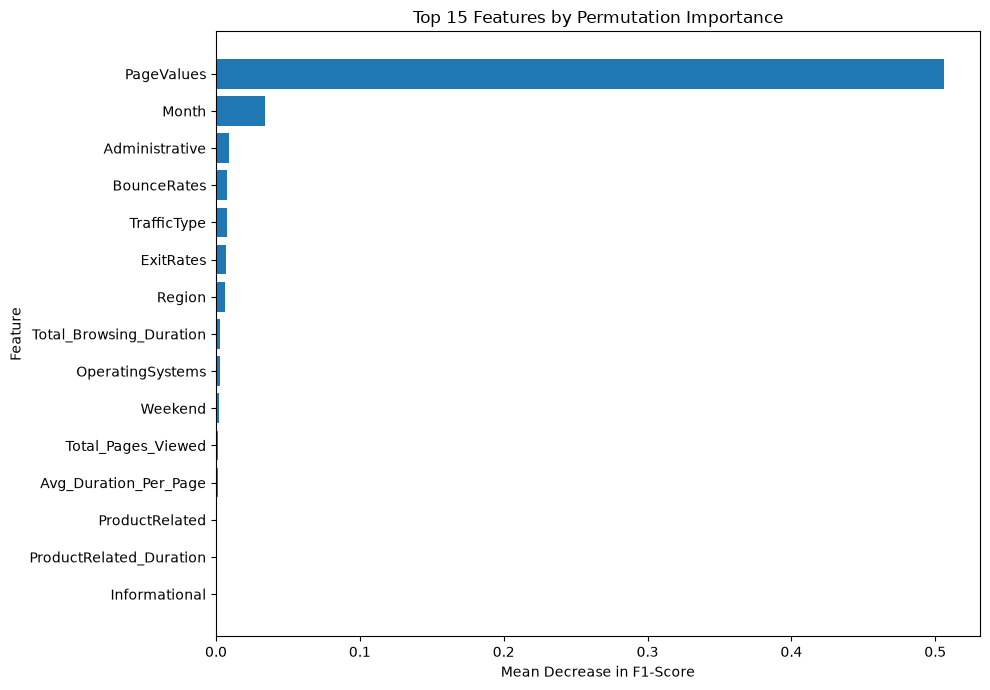

In [13]:
top_permutation_features = (
    permutation_importance_df
    .head(15)
    .sort_values(
        'Importance_Mean',
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation_features['Feature'],
    top_permutation_features['Importance_Mean']
)

plt.xlabel('Mean Decrease in F1-Score')
plt.ylabel('Feature')
plt.title('Top 15 Features by Permutation Importance')

plt.tight_layout()
plt.show()

#### Comparing Feature Importance Methods

In [14]:
importance_comparison = pd.merge(
    aggregated_importance,
    permutation_importance_df[
        ['Feature', 'Importance_Mean']
    ],
    left_on='Original_Feature',
    right_on='Feature',
    how='outer'
)

importance_comparison = (
    importance_comparison
    .drop(columns='Feature')
    .rename(columns={
        'Importance': 'Model_Importance',
        'Importance_Mean': 'Permutation_Importance'
    })
    .fillna(0)
    .sort_values(
        'Model_Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

importance_comparison.head(15)

,Original_Feature,Model_Importance,Permutation_Importance
0,PageValues,0.749870,0.505812
1,Month,0.111678,0.033740
2,TrafficType,0.041473,0.007641
3,Region,0.018451,0.006003
4,Administrative,0.013465,0.009257
5,Product_Page_Share,0.009530,0.000015
6,VisitorType,0.008227,0.000171
7,Informational,0.006623,0.000303
8,Total_Pages_Viewed,0.005852,0.001648
9,Weekend,0.005453,0.002245


#### Visualizing Importance Comparison

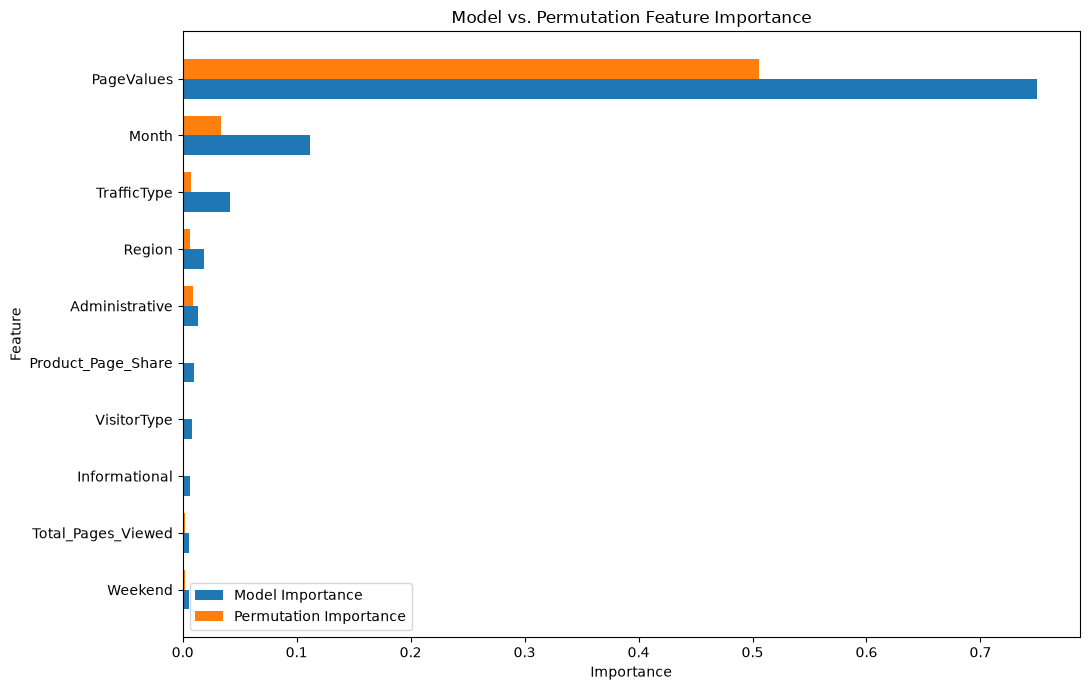

In [15]:
comparison_plot = (
    importance_comparison
    .head(10)
    .sort_values(
        'Model_Importance',
        ascending=True
    )
)

y_positions = np.arange(
    len(comparison_plot)
)

bar_height = 0.35

plt.figure(figsize=(11, 7))

plt.barh(
    y_positions - bar_height / 2,
    comparison_plot['Model_Importance'],
    height=bar_height,
    label='Model Importance'
)

plt.barh(
    y_positions + bar_height / 2,
    comparison_plot['Permutation_Importance'],
    height=bar_height,
    label='Permutation Importance'
)

plt.yticks(
    y_positions,
    comparison_plot['Original_Feature']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Model vs. Permutation Feature Importance')
plt.legend()

plt.tight_layout()
plt.show()

#### Loading Final Model Predictions

In [16]:
final_predictions_data = pd.read_csv(
    '../data/processed/final_model_predictions.csv'
)

final_predictions_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,VisitorType,Weekend,Total_Pages_Viewed,Total_Browsing_Duration,Product_Page_Share,Avg_Duration_Per_Page,Product_Duration_Share,Actual,Predicted,Prediction_Probability
0,0,0.000000,0,0.0,12,482.500000,0.02,0.040000,0.0,0.0,...,Returning_Visitor,False,12,482.500000,1.000000,40.208333,1.000000,False,False,0.134461
1,2,287.200000,0,0.0,16,473.283333,0.00,0.002222,0.0,0.0,...,New_Visitor,True,18,760.483333,0.888889,42.249074,0.622345,False,False,0.078106
2,2,187.900000,4,100.1,29,2107.033333,0.00,0.024242,0.0,0.0,...,Returning_Visitor,False,35,2395.033333,0.828571,68.429524,0.879751,False,False,0.031471
3,7,280.266667,0,0.0,11,329.683333,0.00,0.023077,0.0,0.0,...,Returning_Visitor,False,18,609.950000,0.611111,33.886111,0.540509,False,False,0.062556
4,0,0.000000,0,0.0,5,0.000000,0.20,0.200000,0.0,0.0,...,Returning_Visitor,False,5,0.000000,1.000000,0.000000,0.000000,False,False,0.008396


#### Analyzing False Negative Sessions

In [17]:
false_negatives = final_predictions_data[
    (final_predictions_data['Actual'] == True) &
    (final_predictions_data['Predicted'] == False)
].copy()

false_negatives.shape

(100, 25)

#### Summarizing False Negative Sessions

In [18]:
false_negative_profile = false_negatives[
    [
        'PageValues',
        'ProductRelated',
        'ProductRelated_Duration',
        'Total_Pages_Viewed',
        'Total_Browsing_Duration',
        'Product_Page_Share',
        'Avg_Duration_Per_Page',
        'Product_Duration_Share',
        'BounceRates',
        'ExitRates',
        'Prediction_Probability'
    ]
].describe().T

false_negative_profile[
    ['mean', '50%', 'std', 'min', 'max']
]

,mean,50%,std,min,max
PageValues,4.862544,0.000000,12.983372,0.000000,84.306638
ProductRelated,55.080000,35.500000,56.876915,1.000000,309.000000
ProductRelated_Duration,2209.655731,1413.512500,2564.058841,0.000000,13430.976060
Total_Pages_Viewed,60.050000,40.500000,58.695133,2.000000,319.000000
Total_Browsing_Duration,2431.136578,1613.465000,2652.778452,0.000000,14373.998389
Product_Page_Share,0.855439,0.903846,0.171761,0.200000,1.000000
Avg_Duration_Per_Page,39.123777,34.982924,23.649738,0.000000,163.340891
Product_Duration_Share,0.810323,0.921462,0.274864,0.000000,1.000000
BounceRates,0.009245,0.002936,0.023926,0.000000,0.200000
ExitRates,0.027851,0.022309,0.025835,0.003452,0.200000


This is useful. The key thing is that the median PageValues is 0 and the median prediction probability is only 0.226, even though these sessions actually resulted in purchases. That gives us a concrete profile of the missed conversions.

#### Analyzing False Positive Sessions

In [19]:
false_positives = final_predictions_data[
    (final_predictions_data['Actual'] == False) &
    (final_predictions_data['Predicted'] == True)
].copy()

false_positives.shape

(148, 25)

#### Summarizing False Positive Sessions

In [20]:
false_positive_profile = false_positives[
    [
        'PageValues',
        'ProductRelated',
        'ProductRelated_Duration',
        'Total_Pages_Viewed',
        'Total_Browsing_Duration',
        'Product_Page_Share',
        'Avg_Duration_Per_Page',
        'Product_Duration_Share',
        'BounceRates',
        'ExitRates',
        'Prediction_Probability'
    ]
].describe().T

false_positive_profile[
    ['mean', '50%', 'std', 'min', 'max']
]

,mean,50%,std,min,max
PageValues,22.972320,17.425854,25.368968,0.000000,246.758590
ProductRelated,53.101351,36.000000,48.380400,6.000000,287.000000
ProductRelated_Duration,2028.169336,1344.375028,1932.833128,112.083333,12983.787710
Total_Pages_Viewed,58.554054,42.000000,50.549805,6.000000,304.000000
Total_Browsing_Duration,2235.628498,1541.941666,2056.838119,130.166667,13621.594879
Product_Page_Share,0.890578,0.902574,0.085758,0.638889,1.000000
Avg_Duration_Per_Page,40.742369,34.552421,22.808952,9.264286,145.839149
Product_Duration_Share,0.902547,0.936911,0.110827,0.432615,1.000000
BounceRates,0.007216,0.003573,0.010906,0.000000,0.056667
ExitRates,0.022580,0.019501,0.014576,0.001042,0.090476


- False negatives have a median PageValues of 0 and median prediction probability of 0.226.
- False positives have a median PageValues of 17.43 and median prediction probability of 0.781.
- Most other browsing measures are relatively similar between the two groups.

#### Comparing Model Error Profiles

In [21]:
error_comparison = pd.DataFrame({
    'Metric': [
        'PageValues',
        'ProductRelated',
        'ProductRelated_Duration',
        'Total_Pages_Viewed',
        'Total_Browsing_Duration',
        'Product_Page_Share',
        'Avg_Duration_Per_Page',
        'Product_Duration_Share',
        'BounceRates',
        'ExitRates',
        'Prediction_Probability'
    ],
    'False Negative Median': [
        false_negatives[column].median()
        for column in [
            'PageValues',
            'ProductRelated',
            'ProductRelated_Duration',
            'Total_Pages_Viewed',
            'Total_Browsing_Duration',
            'Product_Page_Share',
            'Avg_Duration_Per_Page',
            'Product_Duration_Share',
            'BounceRates',
            'ExitRates',
            'Prediction_Probability'
        ]
    ],
    'False Positive Median': [
        false_positives[column].median()
        for column in [
            'PageValues',
            'ProductRelated',
            'ProductRelated_Duration',
            'Total_Pages_Viewed',
            'Total_Browsing_Duration',
            'Product_Page_Share',
            'Avg_Duration_Per_Page',
            'Product_Duration_Share',
            'BounceRates',
            'ExitRates',
            'Prediction_Probability'
        ]
    ]
})

error_comparison

,Metric,False Negative Median,False Positive Median
0,PageValues,0.000000,17.425854
1,ProductRelated,35.500000,36.000000
2,ProductRelated_Duration,1413.512500,1344.375028
3,Total_Pages_Viewed,40.500000,42.000000
4,Total_Browsing_Duration,1613.465000,1541.941666
5,Product_Page_Share,0.903846,0.902574
6,Avg_Duration_Per_Page,34.982924,34.552421
7,Product_Duration_Share,0.921462,0.936911
8,BounceRates,0.002936,0.003573
9,ExitRates,0.022309,0.019501


The interesting finding is that browsing intensity is remarkably similar across both error types, while PageValues and model confidence separate them much more strongly. That's a solid explainability finding without overclaiming causality.

#### Visualizing Model Error Profiles

In [22]:
error_profile_plot = error_comparison[
    error_comparison['Metric'].isin([
        'PageValues',
        'Prediction_Probability'
    ])
].copy()

error_profile_plot

,Metric,False Negative Median,False Positive Median
0,PageValues,0.000000,17.425854
10,Prediction_Probability,0.226072,0.781143


#### Visualizing Model Error Profiles

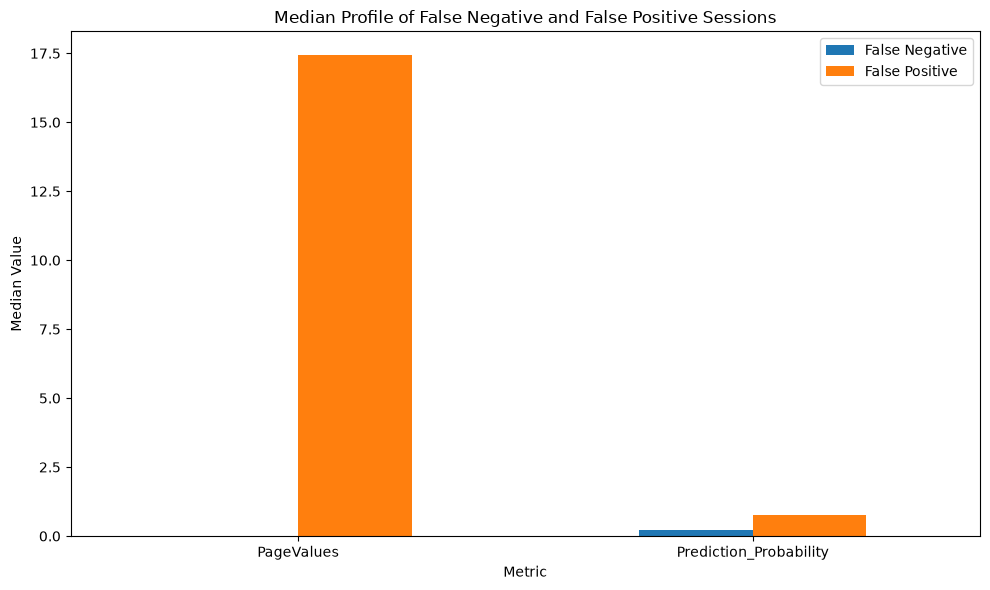

In [23]:
plot_data = error_profile_plot.set_index(
    'Metric'
)

plot_data.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Metric')
plt.ylabel('Median Value')
plt.title('Median Profile of False Negative and False Positive Sessions')
plt.xticks(rotation=0)
plt.legend(
    ['False Negative', 'False Positive']
)

plt.tight_layout()
plt.show()

#### Saving Explainability Results

In [24]:
aggregated_importance.to_csv(
    '../data/processed/feature_importance.csv',
    index=False
)

permutation_importance_df.to_csv(
    '../data/processed/permutation_importance.csv',
    index=False
)

error_comparison.to_csv(
    '../data/processed/error_profile_comparison.csv',
    index=False
)

In [25]:
import os

explainability_files = [
    '../data/processed/feature_importance.csv',
    '../data/processed/permutation_importance.csv',
    '../data/processed/error_profile_comparison.csv'
]

for file in explainability_files:
    print(
        file,
        '→',
        'Exists' if os.path.exists(file) else 'Missing'
    )

../data/processed/feature_importance.csv → Exists
../data/processed/permutation_importance.csv → Exists
../data/processed/error_profile_comparison.csv → Exists


In [26]:
import os

project_structure = {
    'Raw Data': '../data/raw/online_shoppers_intention.csv',
    'Prepared Data': '../data/processed/prepared_data.csv',
    'Feature-Engineered Data': '../data/processed/feature_engineered_data.csv',
    'Train Data': '../data/processed/train_data.csv',
    'Test Data': '../data/processed/test_data.csv',
    'Evaluation Results': '../data/processed/model_evaluation_results.csv',
    'Final Predictions': '../data/processed/final_model_predictions.csv',
    'Threshold Analysis': '../data/processed/threshold_analysis.csv',
    'Feature Importance': '../data/processed/feature_importance.csv',
    'Permutation Importance': '../data/processed/permutation_importance.csv',
    'Error Profile': '../data/processed/error_profile_comparison.csv'
}

for name, path in project_structure.items():
    print(
        f"{name}:",
        "Exists" if os.path.exists(path) else "Missing"
    )

Raw Data: Exists
Prepared Data: Exists
Feature-Engineered Data: Exists
Train Data: Exists
Test Data: Exists
Evaluation Results: Exists
Final Predictions: Exists
Threshold Analysis: Exists
Feature Importance: Exists
Permutation Importance: Exists
Error Profile: Exists


Feature Importance

PageValues is the dominant feature influencing the final Gradient Boosting model's predictions.

Key Observations:
- PageValues accounts for approximately 75.0% of the model's aggregated feature importance.
- Month ranks second at 11.2%, followed by TrafficType at 4.1% and Region at 1.8%.

Business Insights:
- Treat PageValues as a key behavioral signal when designing purchase-oriented customer targeting strategies.
- Monitor the stability of PageValues importance over time before using it as the primary basis for operational decisions.

Permutation Importance

Permutation testing confirms that PageValues has the strongest measurable impact on test-set F1 performance.

Key Observations:
- Permuting PageValues produces a mean F1 decrease of approximately 0.506, substantially higher than the next feature, Month, at 0.034.
- Administrative, BounceRates, TrafficType, and ExitRates also show measurable effects on model performance.

Business Insights:
- Prioritize PageValues when investigating the model's purchase predictions and future feature improvements.
- Retain multiple behavioral and session-context features because model performance is not dependent on PageValues alone.


Importance Method Comparison

Both explainability methods identify PageValues and Month as the strongest original features, while highlighting different secondary signals.

Key Observations:
- PageValues ranks first under both model-based and permutation importance.
- BounceRates and ExitRates receive relatively greater importance under permutation testing than under the model's built-in importance scores.

Business Insights:
- Use both importance methods when interpreting the model rather than relying exclusively on tree-based feature importance.
- Investigate features that gain importance under permutation testing because their contribution may be understated by the model's internal importance measure.

False Negative Profile

Missed purchases often resemble active browsing sessions but lack a strong PageValues signal.

Key Observations:
- False-negative sessions have a median PageValues of 0 and a median prediction probability of 0.226.
- Their median Total_Pages_Viewed is 40.5 and median ProductRelated activity is 35.5, indicating substantial browsing activity despite the missed purchase classification.

Business Insights:
- Investigate sessions with substantial product engagement but low PageValues as potential opportunities for improving purchase detection.
- Consider additional behavioral signals that distinguish high-engagement browsing from eventual purchase activity.

False Positive Profile

False positives exhibit strong purchase-like signals that lead the model to assign high purchase probabilities despite no recorded purchase.

Key Observations:
- False-positive sessions have a median PageValues of 17.43 and median prediction probability of 0.781.
- Their median browsing activity is similar to false negatives, including 36 ProductRelated pages and 42 total pages viewed.

Business Insights:
- Treat high-engagement sessions as potential but not guaranteed purchase opportunities when applying model predictions operationally.
- Investigate additional conversion signals that can separate strong purchase intent from high-intensity non-purchasing sessions.


Overall Explainability Finding

The final model relies most heavily on purchase-related value signals while also incorporating session timing, traffic, geography, and browsing behavior.

Key Observations:
- PageValues, Month, TrafficType, Region, and Administrative activity form the strongest group of original features by model importance.
- Error analysis shows that false positives and false negatives have similar browsing intensity, while PageValues and prediction probability differ substantially.

Business Insights:
- Use the explainability results to support targeted feature refinement rather than treating model predictions as standalone customer decisions.
- Monitor the importance and error patterns as new session data becomes available to identify changes in customer behavior and model reliability.